<a href="https://colab.research.google.com/github/stinemcn/stinemcn/blob/main/Final_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Human Smugglers Advertising Services on Telegram:**
##**How Discourse in Online Messaging Platforms Mirrors Reality**

## **1. Introduction**
Per the European Commission, migrant smuggling into Europe [continues](https://home-affairs.ec.europa.eu/policies/migration-and-asylum/irregular-migration-and-return/migrant-smuggling_en) to be a profitable enterprise for organized criminals, risking the lives of those seeking their services. While many irregular migrants [arrive](https://www.migrationpolicy.org/research/human-smuggling-and-trafficking-europe-comparative-perspective#:~:text=Trafficked%20or%20smuggled%20migrants%20to,are%20used%20for%20traded%20goods) in Europe via the Mediterranean, those traveling over land arrive via Eastern Europe, the Balkans, and Turkey.
Organized criminal groups offering passage from Turkey to neighboring Cyprus, Greece, and Bulgaria often [charge](https://www.migrationpolicy.org/article/turkey-irregular-migration-smuggling-security) anywhere from one to several thousand euros; safety and success are not always guaranteed. While Turkey has taken steps in recent years to combat the ability for smugglers to traffic persons across its borders, crises in the Middle East and Africa, combined with the ability of smugglers to advertise and sell services online have stymied efforts. The messaging platform Telegram offers smugglers a space to recruit travelers

### **1.b) Research Questions and Objectives**

1.   What key words and phrases do smugglers use in their advertisements, or do individuals use when seeking these services on Telegram?
2.   What countries of destination and/or transit are mentioned most frequently by smugglers and those seeking their services?
3. How does the distribution of these countries compare to official immigration statistics collected by the European Commission?

### **1.c) Significance and Importance to Public Policy:**
Turkey and many other countries have worked to combat human trafficking and smuggling over the years, but the challenge persists. By analyzing online discourse related to human smuggling, policymakers can better understand how, why, and where smuggling occurs. In the short term, this will allow for better identification of routes and organized criminal activity behind smuggling; in the long run, this should be indicative of the need to reform migration policies which prevent people from migrating safely and legally.

### **1.d) Hypotheses**

1.   Turkish Human smuggling chats on Telegram will contain words specific to immigration, asylum, and the methods by which passengers travel (boat, road, etc.).
2.   The most frequent countries mentioned in the chat will correlate to the countries receiving the largest number of immigrants from Turkey.
3. Variation between chats will be minimal; chats advertise similar services and service-seekers wish to travel to similar destinations across chats.

### **1.e) Limitations**
Python does not have all the same available tools in Turkish as it does for English. For example, when using nltk, I could add my own Turkish stopwords and thereby eliminate that problem, but I could not lemmatize the Turkish text the same way I could in English. While I debated trying to use SpaCy which has more Turkish language features, for simplicity, I used nltk and several other tools we used in class. While this impacted my research, and limited the likelihood of obtaining verbs as my most common terms due to Turkish grammatical structure, it did not impact my analysis of country name frequencies.


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
path = '/content/drive/MyDrive/Text Analysis in Python/Final_Project'

In [ ]:
import pandas as pd

##**2. Data Collection**
### **2.a) Telegram API**

Of the methods available, I chose to use api access to scrape the contents of Telegram channels. This code, which is saved in a separate Colab Notebook saved in my Github, comes from Ergon Cugler's research and uses the Telethon Library ([SILVA, Ergon Cugler de Moraes. Web Scraping Telegram Posts and Content. (feb) 2023](https://github.com/ergoncugler/web-scraping-telegram/)). This code allowed me extract the message content, author information, reactions, views, and comments from a given Telegram channel. I then imported this data as a csv and used pandas to create a dataframe from the file in Colab, as shown below. Initially, I began with only the dataset below, which contains all content from the channel @avrupa_iltica from 01/01/2024 to 10/01/2024.

### **2.b) European Commission Immigration Data**

Additionally, I downloaded migration data from the European Commission. The Commission collected data from European Union member countries and publicly posts this data for researchers to access. I downloaded the most recently available migration data (from 2022) which allowed to me to sort by country of previous residence.


In [ ]:
data_df= pd.read_csv(f"{path}/Telegram_Download.csv", delimiter=',', encoding='utf-8')
pd.set_option('display.max_colwidth', None)

In [ ]:
data_df

,Type,Group,Author ID,Content,Date,Message ID,Author,Views,Reactions,Shares,Media,Url,Comments List
0,text,@avrupa_iltica,NaN,WhatsApp’dan ulaşın lütfen +49 157 76986292,2024-09-30 20:41:52,29422,NaN,NaN,NaN,NaN,False,https://t.me/avrupa_iltica/29422,[]
1,text,@avrupa_iltica,NaN,Ben gönderiyorum buyur kardeşim,2024-09-30 20:40:11,29421,NaN,NaN,NaN,NaN,False,https://t.me/avrupa_iltica/29421,[]
2,text,@avrupa_iltica,5.960956e+09,Gönderim kim sağlıyor,2024-09-30 20:36:40,29420,NaN,NaN,NaN,NaN,False,https://t.me/avrupa_iltica/29420,[]
3,text,@avrupa_iltica,NaN,Sırbistan Belgrad üzeri bir adım yürüme olmadan önden bir kuruş ödeme yapmadan İtalya Almanya 🇩🇪 gönderimler devam ediyor \n\nOrmana girmeden \nDereden geçmeden \nÜstün başın yağmur çamur olmadan \nPolise yakalanmadan\nNezerate kampa girmeden \nParmak izi vermeden \nTer temiz bir şekilde Avrupa’ya gitmek isteyenler WhatsApp’dan ulaşın +49 157 76986292,2024-09-30 11:39:28,29415,NaN,NaN,NaN,NaN,True,https://t.me/avrupa_iltica/29415,"[{""Type"": ""comment"", ""Comment Group"": ""@avrupa_iltica"", ""Comment Author ID"": null, ""Comment Content"": ""WhatsApp\u2019dan ula\u015f\u0131n l\u00fctfen +49\u00a0157\u00a076986292"", ""Comment Date"": ""2024-09-30 20:41:52"", ""Comment Message ID"": 29422, ""Comment Author"": null, ""Comment Views"": null, ""Comment Reactions"": """", ""Comment Shares"": null, ""Comment Media"": ""False"", ""Comment Url"": ""https://t.me/avrupa_iltica/29415?comment=29422""}, {""Type"": ""comment"", ""Comment Group"": ""@avrupa_iltica"", ""Comment Author ID"": null, ""Comment Content"": ""Ben g\u00f6nderiyorum buyur karde\u015fim"", ""Comment Date"": ""2024-09-30 20:40:11"", ""Comment Message ID"": 29421, ""Comment Author"": null, ""Comment Views"": null, ""Comment Reactions"": """", ""Comment Shares"": null, ""Comment Media"": ""False"", ""Comment Url"": ""https://t.me/avrupa_iltica/29415?comment=29421""}, {""Type"": ""comment"", ""Comment Group"": ""@avrupa_iltica"", ""Comment Author ID"": 5960955802, ""Comment Content"": ""G\u00f6nderim kim sa\u011fl\u0131yor"", ""Comment Date"": ""2024-09-30 20:36:40"", ""Comment Message ID"": 29420, ""Comment Author"": null, ""Comment Views"": null, ""Comment Reactions"": """", ""Comment Shares"": null, ""Comment Media"": ""False"", ""Comment Url"": ""https://t.me/avrupa_iltica/29415?comment=29420""}]"
4,text,@avrupa_iltica,1.341144e+09,Pasaportun üzerinde olmasın ama bu demek değildir pasaportunu imha et. Pasaportunu daha sonradan sana ulaştıracak birine vermen senin yararına. Ayrıca Slovenya daki parmak izi sıkıntı çıkarmaz sana,2024-09-30 10:11:35,29414,NaN,NaN,👍 1,NaN,False,https://t.me/avrupa_iltica/29414,[]
...,...,...,...,...,...,...,...,...,...,...,...,...,...
4397,text,@avrupa_iltica,6.504192e+09,Tüm avrupaya yardımcı olunur,2024-01-01 10:10:03,13405,NaN,NaN,NaN,NaN,False,https://t.me/avrupa_iltica/13405,[]
4398,text,@avrupa_iltica,6.504192e+09,+1 (435) 239‑7031,2024-01-01 10:10:03,13404,NaN,NaN,NaN,NaN,False,https://t.me/avrupa_iltica/13404,[]
4399,text,@avrupa_iltica,6.243983e+09,NaN,2024-01-01 09:40:26,13402,NaN,NaN,NaN,NaN,True,https://t.me/avrupa_iltica/13402,[]
4400,text,@avrupa_iltica,1.604896e+09,Merhabalar! İltica dosyası nasıl hazırlatabilirim acaba??,2024-01-01 07:35:49,13401,NaN,NaN,NaN,NaN,False,https://t.me/avrupa_iltica/13401,"[{""Type"": ""comment"", ""Comment Group"": ""@avrupa_iltica"", ""Comment Author ID"": 6443822273, ""Comment Content"": ""\u00d6zelden ula\u015f"", ""Comment Date"": ""2024-01-01 12:13:53"", ""Comment Message ID"": 13408, ""Comment Author"": null, ""Comment Views"": null, ""Comment Reactions"": """", ""Comment Shares"": null, ""Comment Media"": ""False"", ""Comment Url"": ""https://t.me/avrupa_iltica/13401?comment=13408""}]"


In [ ]:
data_df.dtypes

,0
Type,object
Group,object
Author ID,float64
Content,object
Date,object
Message ID,int64
Author,float64
Views,float64
Reactions,object
Shares,float64


Above, I examined the data and the data types. The date as produced from the CSV was not saved in the datetime format, so below I changed that column of data into the appropriate type.

In [ ]:
data_df['Date'] = pd.to_datetime(data_df['Date'], format='ISO8601')

In [ ]:
data_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4402 entries, 0 to 4401
Data columns (total 13 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Type           4402 non-null   object        
 1   Group          4402 non-null   object        
 2   Author ID      4059 non-null   float64       
 3   Content        4315 non-null   object        
 4   Date           4402 non-null   datetime64[ns]
 5   Message ID     4402 non-null   int64         
 6   Author         0 non-null      float64       
 7   Views          2 non-null      float64       
 8   Reactions      225 non-null    object        
 9   Shares         2 non-null      float64       
 10  Media          4402 non-null   bool          
 11  Url            4402 non-null   object        
 12  Comments List  4402 non-null   object        
dtypes: bool(1), datetime64[ns](1), float64(4), int64(1), object(6)
memory usage: 417.1+ KB


Next, I combined all the content in the Content column (i.e. what users wrote in their messages) and combined it into a single string of text to analyze. While this does not allow for analysis of trends across the period, it allows me to create a large corpus of text from over 4,000 posts.

In [ ]:
combined_content = data_df['Content'].to_string(index=False)
with open('combined_content.txt', 'w') as f:
  # Write the string to the file
  f.write(combined_content)

In [ ]:
print(combined_content)

                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                   WhatsApp’dan ulaşın lütfen +49 157 76986292
                                                                                                                                                                                                                                                                                         

In [ ]:
import nltk
import matplotlib
%matplotlib inline

In [ ]:
!pip install --upgrade nltk

In [ ]:
# Download the required resources
nltk.download('wordnet')
nltk.download('omw-1.4')
nltk.download('averaged_perceptron_tagger_eng')
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')


from nltk.stem import WordNetLemmatizer
from nltk.corpus import wordnet
from nltk.probability import FreqDist
from nltk import pos_tag
from nltk.corpus import stopwords
stops = stopwords.words('english')



lemmatizer = WordNetLemmatizer()


def get_wordnet_pos(word):
    """Map POS tag to first character lemmatize() accepts"""
    tag = pos_tag([word])[0][1][0].upper()  # Get the first letter of the POS tag
    tag_dict = {
        'J': wordnet.ADJ,  # Adjective
        'N': wordnet.NOUN,  # Noun
        'V': wordnet.VERB,  # Verb
        'R': wordnet.ADV    # Adverb
    }
    return tag_dict.get(tag, wordnet.NOUN)  # Default to noun if not found

from wordcloud import WordCloud
import matplotlib.pyplot as plt

import glob

[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /root/nltk_data...
[nltk_data]   Unzipping taggers/averaged_perceptron_tagger_eng.zip.
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


In [ ]:
ls

combined_content.txt  drive/  sample_data/


In [ ]:
directory = f"{path}/"
files = glob.glob(f"{directory}/combined_content.txt")

## **3. Data Analysis**
I chose to restrict my research to data beginning in 2024 (January 1, 2024) to approximately the start of my project timelines (October 1, 2024). I have followed Turkish human smuggling channels in Telegram for several months, so I selected two of the channels that I knew to be active during the time period and which contained over 1,000 users. From these channels, I used a scraping tool from GitHub to retrieve all of the posts in the channel during the time frame and saved the data as a csv file to analyze in Python. Then, I treated the data and used the following analytical process:


1.   To test my first research question, I combined the text from all posts within the period (as shown above) into one string; from this, I removed both English stopwords and a custom list of Turkish stopwords, and then tokenized the text. This provided me with ten months of content to analyze. From this cleaned corpus, I used FreqDist to examine and plot the most frequently used words within the chat.
2.   
Next, I wanted to analyze which countries were mentioned most frequently within the channel. I restricted my research to European countries so that I could later compare results to data collected by the European Commission. I used ChatGPT to help create a code which would identify the Turkish names of European countries within the text, map those names to their English equivalents, and then count the frequency of mentions of each country name. This code then printed the frequencies from greatest to least.
3.
Lastly, I wanted to compare the frequency of country names mentioned in the channel to the countries of immigration in Europe most frequently traveled to from Turkey. The European Commission collects data from European countries regarding immigration of persons and restricted by country of previous residence. I chose to use this dataset because it would allow me to examine individuals who migrated from Turkey but were not necessarily Turkish citizens. This is important because many individuals use Turkey as a transit country between the Middle East and Africa, and this dataset would allow me to capture a wider range of data, similar to the public nature of online chats and channels which are not restricted to any nationality. I downloaded and imported this data.


In [ ]:
from nltk.corpus import stopwords

In [ ]:
# Source: https://github.com/stopwords-iso/stopwords-tr
TURK_STOP_WORDS = TURK_STOP_WORDS = set("""
arkadaşlar acaba acep adamakıllı adeta ait ama amma anca ancak arada artık aslında aynen ayrıca az açıkça açıkçası
bana bari bazen bazı bazısı bazısına bazısında bazısından bazısını bazısının başkası başkasına başkasında başkasından
başkasını başkasının başka belki ben bende benden beni benim beri beriki berikinin berikiyi berisi bilcümle bile binaen
binaenaleyh bi bir biraz birazdan birbiri birbirine birbirini birbirinin birbirinde birbirinden birden birdenbire biri
birine birini birinin birinde birinden birice birileri birilerinde birilerinden birilerine birilerini birilerinin birisi
birisine birisini birisinin birisinde birisinden birkaç birkaçı birkaçına birkaçını birkaçının birkaçında birkaçından
birkez birlikte birçok birçoğu birçoğuna birçoğunda birçoğundan birçoğunu birçoğunun birşey birşeyi bitevi biteviye
bittabi biz bizatihi bizce bizcileyin bizden bize bizi bizim bizimki bizzat boşuna bu buna bunda bundan bunlar bunları
bunların bunu bunun buracıkta burada buradan burası burasına burasını burasının burasında burasından böyle böylece
böylecene böylelikle böylemesine böylesine büsbütün bütün cuk cümlesi cümlesine cümlesini cümlesinin cümlesinden cümlemize
cümlemizi cümlemizden çabuk çabukça çeşitli çok çokları çoklarınca çokluk çoklukla çokça çoğu çoğun çoğunca çoğunda
çoğundan çoğunlukla çoğunu çoğunun çünkü da daha dahası dahi dahil dahilen daima dair dan dayanarak de defa dek demin
demincek deminden den denli derakap derhal derken değil değin diye diğer diğeri diğerine diğerini diğerinden dolayı
dolayısıyla doğru edecek eden ederek edilecek ediliyor edilmesi ediyor elbet elbette emme en enikonu epey epeyce epeyi
esasen esnasında etmesi etraflı etraflıca etti ettiği ettiğini evleviyetle evet evvel evvela evvelce evvelden evvelemirde
evveli eğer fakat filanca filancanın gah gayet gayetle gayri gayrı gelgelelim gene gerek gerçi geçende geçenlerde gibi
gibilerden gibisinden gine göre gırla hakeza halbuki halen halihazırda haliyle handiyse hangi hangisi hangisine hangisinde
hangisinden hani hariç hasebiyle hasılı hatta hele hem henüz hep hepsi hepsini hepsinin hepsinde hepsinden her herhangi
herkes herkesi herkesin herkesten hiç hiçbir hiçbiri hiçbirine hiçbirini hiçbirinin hiçbirinde hiçbirinden hoş hulasaten
iken ila ile ilen ilgili ilk illa illaki imdi indinde inen insermi ise ister itibaren itibariyle itibarıyla iyi iyice
iyicene için iş işte kadar kaffesi kah kala kanımca kardeşim karşın kaynak kaçı kaçına kaçında kaçından kaçını kaçının
kelli kendi kendilerinde kendilerinden kendilerine kendilerini kendilerinin kendini kendisi kendisinde kendisinden
kendisine kendisini kendisinin kere kez keza kezalik keşke ki kim kimden kime kimi kiminin kimisi kimisinde kimisinden
kimisine kimisinin kimse kimsecik kimsecikler külliyen kısaca kısacası lakin leh lütfen maada madem mademki mamafih mebni
meğer meğerki meğerse merhaba mu mü mı mi nan nasıl nasılsa nazaran naşi ne neden nedeniyle nedenle nedenler nedenlerden
nedense nerde nerden nerdeyse nere nerede nereden neredeyse neresi nereye netekim neye neyi neyse nice nihayet nihayetinde
nitekim niye niçin o olan olarak oldu olduklarını oldukça olduğu olduğunu olmak olması olsa olsun olup olur olursa oluyor
ona onca onculayın onda ondan onlar onlara onlardan onları onların onu onun ora oracık oracıkta orada oradan oranca oranla
oraya oysa oysaki öbür öbürkü öbürü öbüründe öbüründen öbürüne öbürünü önce önceden önceleri öncelikle öteki ötekisi öyle
öylece öylelikle öylemesine öz pek pekala peki pekçe peyderpey rağmen sadece sahi sahiden sana sanki sen senden seni senin
siz sizden sizi sizin sonra sonradan sonraları sonunda şayet şey şeyden şeyi şeyler şu şuna şuncacık şunda şundan şunlar
şunları şunların şunu şunun şura şuracık şuracıkta şurası şöyle şimdi tabii tam tamam tamamen tamamıyla tarafından tek
tüm üzere var varsa varmı varmi vardı vasıtasıyla ve velev velhasıl velhasılıkelam veya veyahut ya yahut yakinen yakında
yakından yakınlarda yalnız yalnızca yani yapacak yapmak yaptı yaptıkları yaptığı yaptığını yapılan yapılması yapıyor
yeniden yenilerde yerine yine yok yoksa yoluyla yüzünden zarfında zaten zati zira 157 76986292 1 2 3
""".split())


In [ ]:
stop_words = set(stopwords.words('english'))

In [ ]:
stop_words.update(TURK_STOP_WORDS)  # Use update() to add multiple words

In [ ]:
print(stop_words)

{'above', 'zarfında', 'birçoğu', 'kezalik', 'tamam', 'nan', '157', 'ondan', 'this', 'kimisinde', 'bende', 'mightn', 'şeyi', 'his', 'cümlemizi', "you're", 'ettiğini', 'o', 'mademki', 'by', 'ours', 'ne', 'onları', 'şunların', 'şu', 'cümlesine', 'acaba', 'yahut', 'birbirinin', 'ilgili', 'hiçbirinden', 'çokları', 'burasına', 'myself', 'beriki', 'olarak', "shouldn't", 'gibi', 'emme', 'nedenler', 'bari', 'şuna', 'birlikte', 'birisi', 'maada', 'ya', 'varmi', 'kanımca', 'senin', 'dan', 'when', 'birice', 'iş', 'vardı', 'hiçbir', 'from', 'that', 'külliyen', 'işte', 'hem', 'nedenle', 'hers', 'why', 'olduklarını', 'çoğunu', 'sonunda', "you'll", 'dolayı', 'been', 'olsun', 'll', 'diye', 'sonradan', 'kendisine', 'itibaren', 'itibarıyla', 'hangisinde', 'pekala', 'birşey', 'demincek', 'değil', 'öbürü', 'gibisinden', 'kimisinin', 'couldn', 'epey', 'öylemesine', 'yalnız', 'hasebiyle', 'buradan', 'çabuk', 'oracıkta', 'zira', 'ain', 'ancak', 'nerde', 'illa', 'böylemesine', 'yaptıkları', 'gene', 'kelli', 'b

In [ ]:
tokens = nltk.word_tokenize(combined_content)

In [ ]:
nltk_combined = nltk.Text(tokens)

In [ ]:
tokens_lower = [t.lower() for t in nltk_combined if t.isalnum()] #

In [ ]:
no_stops = [t for t in tokens_lower if t not in stop_words]

In [ ]:
print(no_stops)

['whatsapp', 'ulaşın', 'gönderiyorum', 'buyur', 'gönderim', 'sağlıyor', 'sırbistan', 'belgrad', 'üzeri', 'adım', 'yürüme', 'olmadan', 'önden', 'kuruş', 'ödeme', 'yapmadan', 'i̇talya', 'almanya', 'gönderimler', 'devam', 'girmeden', 'geçmeden', 'başın', 'yağmur', 'çamur', 'olmadan', 'kampa', 'girmeden', 'izi', 'vermeden', 'temiz', 'şekilde', 'avrupa', 'gitmek', 'isteyenler', 'whatsapp', 'ulaşın', 'pasaportun', 'üzerinde', 'olmasın', 'demek', 'değildir', 'pasaportunu', 'imha', 'et', 'pasaportunu', 'ulaştıracak', 'vermen', 'yararına', 'slovenya', 'daki', 'parmak', 'izi', 'sıkıntı', 'çıkarmaz', 'yunanistan', 'kamp', 'teslim', 'yolumuz', 'aktifdir', 'detaylı', 'bilgi', 'whatsapp', 'iletişime', 'geçiniz', 'bilgisi', 'slovenya', 'parmak', 'izi', 'hakkında', 'çıkmıyor', 'duyuyorum', 'gerçek', 'çevresinde', 'gören', 'duyan', 'gün', 'tutar', 'salat', 'parmak', 'izi', 'bitşey', 'pasaportun', 'yokken', 'bişey', 'yapamazlar', 'saba', 'pasaportu', 'yak', 'gitsin', 'kolay', 'gelsin', 'slovenyada', 'ya

In [ ]:
type(no_stops)

list

In [ ]:
my_dist = FreqDist(no_stops)


### **3.a) General Word Frequency Analysis**

I used FreqDist to analyze the most frequently used words across the Telegram channel @avrupa_iltica. Interestingly, the words "arkadaşlar" and "kardeşim" were the first and third most popular words, which I subsequently removed as stopwords. These mean "friend" and "sibling," respectively, and are common in greetings with friends - I did not expect to see this group addressed this way. Many of the posts within these channels use colloquial, familial terms like friend, sibling, or "abi" (brother) to engender feelings of safety. The trips that these smugglers offer can be dangerous, so most advertisements tend to present them as safe, well-worn routes, led by capable, familiar guides.

This frequency distribution also draws attention to several other interesting keywords. The second most common word, "iltica," means asylum in English. Other words related to illegal migration include "kaçak" (61 instances), which means escape, and "yol," which means road or route.

Additionally, the frequency distribution showed that Germany, Europe, and Bosnia were frequently mentioned throughout the channel. As Germany hosts the largest Turkish population outside of Turkey (3 million people), this logically follows. Similarly, Bosnia and Herzegovina is a common country for smugglers to begin their routes, because Turkish passport holders can visit Bosnia without a visa.

The following list shows the English translations of the most frequently used words in the corpus, stopwords omitted.

*   arkadaşlar (196) - friends
*   iltica (169) - asylum
*   kardeşim (144) - sibling/brother
* almanya (123) - Germany
* yol (89) - road
*  avrupa (87) - Europe
* parmak (84) - finger ("parmak izi" is fingerprint)
* yardımcı (82) - helpful
* abi (77) - brother
* gitmek (75) - to go
* euro (75) - euro
* bosna (73) - Bosnia
* izi (68) - trace
* bilgi (68) - knowledge/information
* özelden (66) - privately
* ay (66) - month
* evet (65) - yes
* kaçak (61) - escape/runaway
* lazım (58) - need
* whatsapp (55) - WhatsApp

<Axes: xlabel='Samples', ylabel='Counts'>

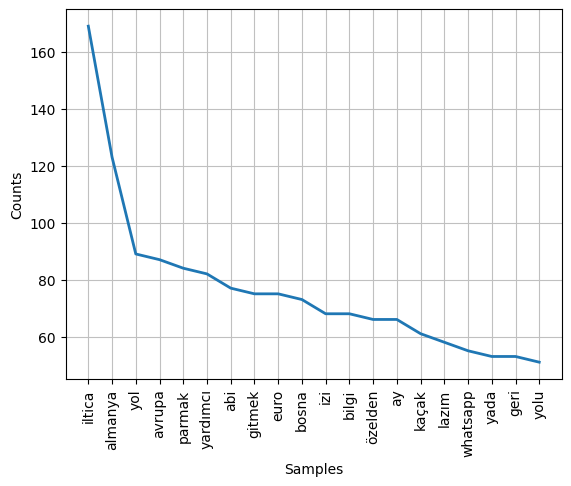

In [ ]:
my_dist.plot(20)

In [ ]:
my_dist.most_common(20)

[('iltica', 169),
 ('almanya', 123),
 ('yol', 89),
 ('avrupa', 87),
 ('parmak', 84),
 ('yardımcı', 82),
 ('abi', 77),
 ('gitmek', 75),
 ('euro', 75),
 ('bosna', 73),
 ('izi', 68),
 ('bilgi', 68),
 ('özelden', 66),
 ('ay', 66),
 ('kaçak', 61),
 ('lazım', 58),
 ('whatsapp', 55),
 ('yada', 53),
 ('geri', 53),
 ('yolu', 51)]

### **3.b) Country Frequency Analysis**

Next, I wanted to analyze which countries were most frequently mentioned by name. I used ChatGPT to help write this code, which begins with a list of European country names in Turkish, counts the frequency with which each country appears within the text corpus, and then sorts the countries by their frequency.

In [ ]:
# List of Turkish words for European countries
european_countries_tr = [
    "Almanya", "Fransa", "İngiltere", "İtalya", "İspanya", "Portekiz", "Hollanda", "Belçika",
    "İsviçre", "Avusturya", "Yunanistan", "İzlanda", "Norveç", "Danimarka", "İsveç", "Finlandiya",
    "İrlanda", "Polonya", "Çekya", "Macaristan", "Slovakya", "Slovenya", "Hırvatistan",
    "Bosna", "Sırbistan", "Karadağ", "Arnavutluk", "Makedonya", "Litvanya", "Letonya",
    "Estonya", "Romanya", "Bulgaristan", "Ukrayna", "Beyaz Rusya", "Rusya"

]

# Mapping of Turkish country names to English
country_name_mapping = {
    "Almanya": "Germany", "Fransa": "France", "İngiltere": "United Kingdom", "İtalya": "Italy",
    "İspanya": "Spain", "Portekiz": "Portugal", "Hollanda": "Netherlands", "Belçika": "Belgium",
    "İsviçre": "Switzerland", "Avusturya": "Austria", "Yunanistan": "Greece", "İzlanda": "Iceland",
    "Norveç": "Norway", "Danimarka": "Denmark", "İsveç": "Sweden", "Finlandiya": "Finland",
    "İrlanda": "Ireland", "Polonya": "Poland", "Çekya": "Czechia", "Macaristan": "Hungary",
    "Slovakya": "Slovakia", "Slovenya": "Slovenia", "Hırvatistan": "Croatia", "Bosna": "Bosnia",
    "Sırbistan": "Serbia", "Karadağ": "Montenegro", "Arnavutluk": "Albania", "Makedonya": "North Macedonia",
    "Litvanya": "Lithuania", "Letonya": "Latvia", "Estonya": "Estonia", "Romanya": "Romania",
    "Bulgaristan": "Bulgaria", "Ukrayna": "Ukraine", "Beyaz Rusya": "Belarus", "Rusya": "Russia"
}

def count_country_frequencies(no_stops):
    # Dictionary to store frequencies of each country in the text
    country_frequencies = {country: no_stops.count(country.lower()) for country in european_countries_tr}

    # Sort countries by frequency in descending order
    sorted_countries = dict(sorted(country_frequencies.items(), key=lambda item: item[1], reverse=True))

    return sorted_countries


country_frequencies = count_country_frequencies(no_stops)

# Display the results with English country names
for country_tr, count in country_frequencies.items():
    if count > 0:
        country_en = country_name_mapping[country_tr]
        print(f"{country_en}: {count}")


Germany: 123
Bosnia: 73
Italy: 40
Greece: 40
United Kingdom: 30
Netherlands: 30
Austria: 27
France: 24
Bulgaria: 23
Serbia: 21
Poland: 19
Croatia: 14
Switzerland: 13
Slovenia: 13
Belgium: 10
Albania: 8
Montenegro: 7
Denmark: 5
Hungary: 5
Sweden: 4
North Macedonia: 4
Romania: 4
Norway: 3
Slovakia: 3
Russia: 3
Spain: 2
Finland: 2
Czechia: 2
Ukraine: 2


The code produced a list of countries and their frequencies within the text, sorted by most frequent to least frequent. As stated above, Germany is logically the most frequently mentioned country, as Germany contains the largest Turkish population outside of Turkey. Similarly, the frequencies of Bosnia, Italy, and Greece are all logical. Bosnia is frequently used as a starting point by smugglers because Turkish citizens do not need a visa to visit Bosnia; Italy is a common destination, particularly the city of Trieste just past the Slovenian border; and, Greece is Turkey's neighbor. I then wanted to display these results graphically. I used ChatGPT to help write code which allowed me to use the frequencies of the countries mentioned to create a bar chart, as shown below.


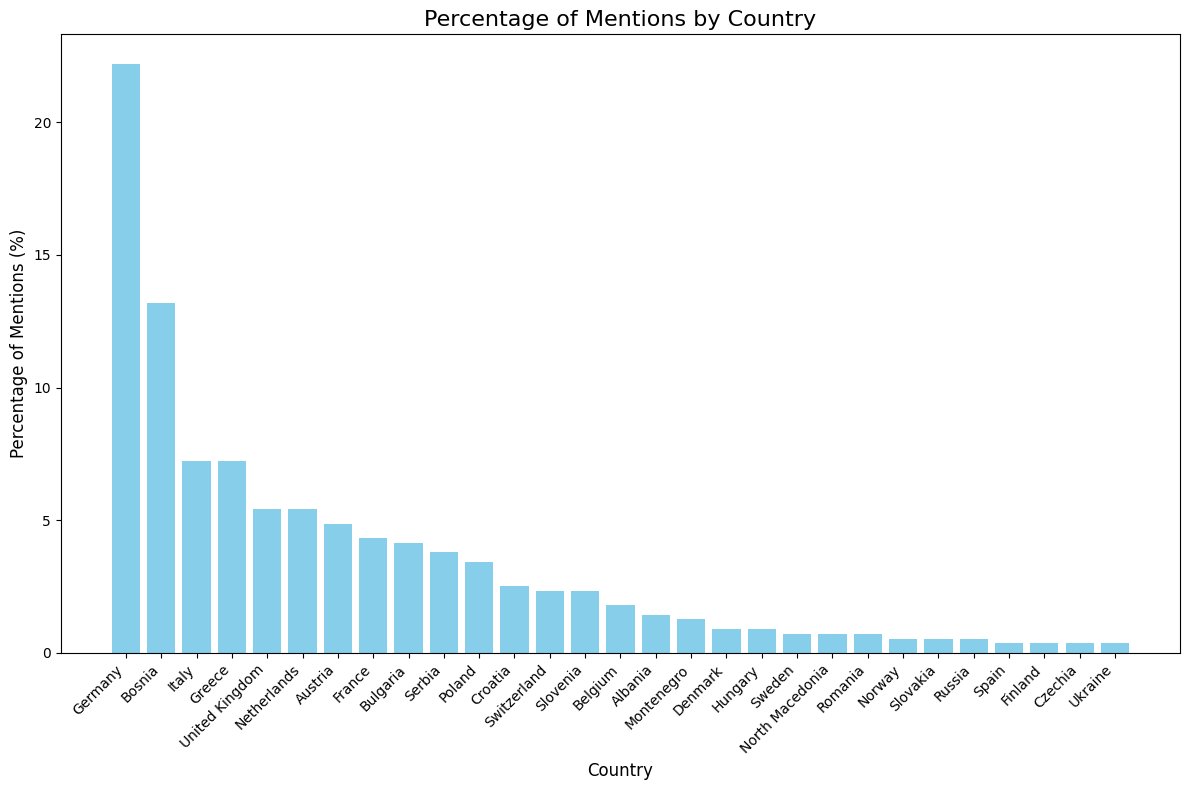

In [ ]:


# Count frequencies
def count_country_frequencies(no_stops):
    # Dictionary to store frequencies of each country in the text
    country_frequencies = {country: no_stops.count(country.lower()) for country in european_countries_tr}

    # Sort countries by frequency in descending order
    sorted_countries = dict(sorted(country_frequencies.items(), key=lambda item: item[1], reverse=True))

    return sorted_countries

country_frequencies = count_country_frequencies(no_stops)

# Calculate total mentions
total_mentions = sum(country_frequencies.values())

# Filter countries with nonzero frequencies and map to English
filtered_countries = {
    country_name_mapping[country_tr]: count
    for country_tr, count in country_frequencies.items() if count > 0
}

# Calculate percentages
percentages = {
    country: (count / total_mentions) * 100 for country, count in filtered_countries.items()
}

# Plotting the data
def plot_country_percentages(countries, percentages):
    # Sort data by percentage (descending order)
    sorted_data = sorted(percentages.items(), key=lambda x: x[1], reverse=True)
    sorted_countries, sorted_percentages = zip(*sorted_data)

    # Create the bar plot
    plt.figure(figsize=(12, 8))
    plt.bar(sorted_countries, sorted_percentages, color='skyblue')
    plt.xlabel('Country', fontsize=12)
    plt.ylabel('Percentage of Mentions (%)', fontsize=12)
    plt.title('Percentage of Mentions by Country', fontsize=16)
    plt.xticks(rotation=45, ha='right', fontsize=10)
    plt.tight_layout()
    plt.show()

# Call the plotting function
plot_country_percentages(filtered_countries.keys(), percentages)


While this graph provides utility in that it shows the distribution of countries mentioned, to compare this data to the European Commission data, I had to remove countries mentioned which did not provide migration reporting data to the commission. Below, I manually selected the Telegram data which corresponded to a matching reporting country within the Commission's dataset. I used this restricted data to create a smaller graph showing the distribution of only these countries.

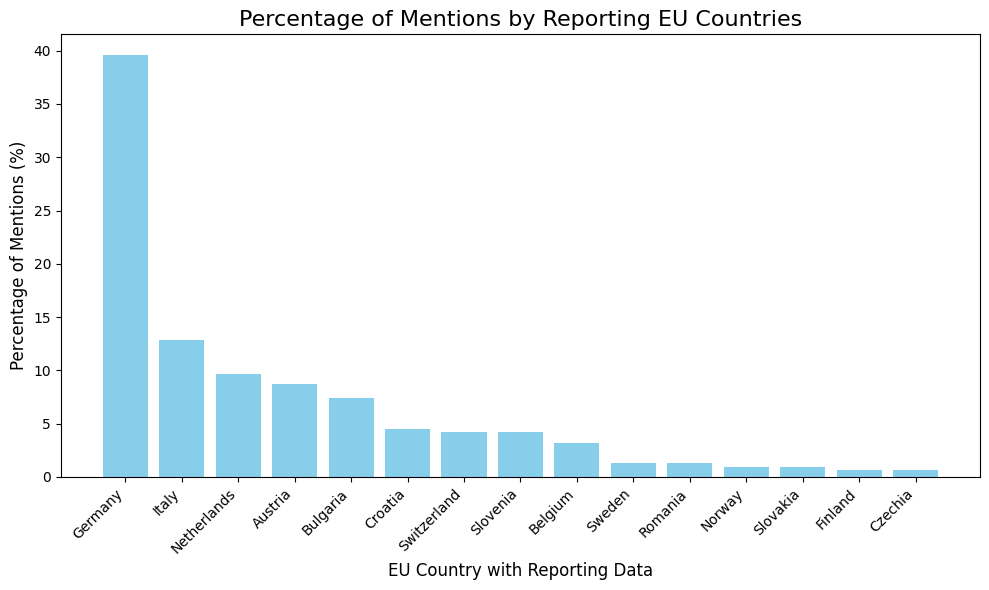

In [ ]:
EU_Countries_With_Reporting_Data = [ "Germany", "Italy", "Netherlands",
"Austria", "Bulgaria", "Croatia", "Switzerland", "Slovenia", "Belgium",
"Sweden", "Romania", "Norway", "Slovakia", "Finland", "Czechia" ]

EU_Frequencies = [123, 40, 30, 27, 23, 14, 13, 13, 10, 4, 4, 3, 3, 2, 2]

# Calculate total mentions
total_mentions_EU_Countries = sum(EU_Frequencies)

# Calculate percentages
EU_percentages = [(freq / total_mentions_EU_Countries) * 100 for freq in EU_Frequencies]

# Plotting the data
def plot_country_percentages(EU_Countries_With_Reporting_Data, EU_percentages):
    # Sort data by percentage (descending order)
    sorted_data = sorted(zip(EU_Countries_With_Reporting_Data, EU_percentages), key=lambda x: x[1], reverse=True)
    sorted_countries, sorted_percentages = zip(*sorted_data)

    # Create the bar plot
    plt.figure(figsize=(10, 6))
    plt.bar(sorted_countries, sorted_percentages, color='skyblue')
    plt.xlabel('EU Country with Reporting Data', fontsize=12)
    plt.ylabel('Percentage of Mentions (%)', fontsize=12)
    plt.title('Percentage of Mentions by Reporting EU Countries', fontsize=16)
    plt.xticks(rotation=45, ha='right', fontsize=10)
    plt.tight_layout()
    plt.show()

# Call the plotting function
plot_country_percentages(EU_Countries_With_Reporting_Data, EU_percentages)


Next, I saved the percentages as a variable so that I could create a dataframe using these percentages and their corresponding countries. I wanted to attach this column of percentages to the dataframe of migration data I obtained from the commission so that I could graph and compare the data.

In [ ]:
EU_percentages = [39.549839228295816,
 12.861736334405144,
 9.646302250803858,
 8.681672025723474,
 7.395498392282958,
 4.501607717041801,
 4.180064308681672,
 4.180064308681672,
 3.215434083601286,
 1.2861736334405145,
 1.2861736334405145,
 0.964630225080386,
 0.964630225080386,
 0.6430868167202572,
 0.6430868167202572]

geo = [ "Germany", "Italy", "Netherlands", "Austria", "Bulgaria", "Croatia", "Switzerland", "Slovenia", "Belgium", "Sweden", "Romania", "Norway", "Slovakia", "Finland", "Czechia" ]
dictionary = {'geo': geo, 'Percentages of Mentions': EU_percentages}
Telegram_ReportingCountries_df = pd.DataFrame(dictionary)

Telegram_ReportingCountries_df

,geo,Percentages of Mentions
0,Germany,39.549839
1,Italy,12.861736
2,Netherlands,9.646302
3,Austria,8.681672
4,Bulgaria,7.395498
5,Croatia,4.501608
6,Switzerland,4.180064
7,Slovenia,4.180064
8,Belgium,3.215434
9,Sweden,1.286174


### **3.c) Comparing Telegram Data to the European Commission Data**

Next, I imported the European Commission dataset for 2022 and added the data I had derived from the frequency of countries mentioned in the Telegram channel. This dataset from the European Commission contains 2022 data from all reporting countries regarding immigrants whose last country of residence was Turkey. (Note: the data I obtained from Telegram is from 2024; the Commission did not yet have a 2023 or 2024 dataset which I could restrict by country of previous residence).

In [ ]:
migration_df= pd.read_csv(f"{path}/Migration_From_Turkey_Updated_estat_migr_imm5prv_filtered_en (2).csv", delimiter=',', encoding='utf-8')
pd.set_option('display.max_colwidth', None)

In [ ]:
migration_df

,DATAFLOW,LAST UPDATE,freq,partner,agedef,age,unit,sex,geo,TIME_PERIOD,OBS_VALUE,OBS_FLAG
0,ESTAT:MIGR_IMM5PRV(1.0),13/11/24 23:00:00,Annual,Türkiye,Age reached during the year,Total,Number,Total,Austria,2022,4486,NaN
1,ESTAT:MIGR_IMM5PRV(1.0),13/11/24 23:00:00,Annual,Türkiye,Age reached during the year,Total,Number,Total,Belgium,2022,5756,NaN
2,ESTAT:MIGR_IMM5PRV(1.0),13/11/24 23:00:00,Annual,Türkiye,Age reached during the year,Total,Number,Total,Bulgaria,2022,9378,NaN
3,ESTAT:MIGR_IMM5PRV(1.0),13/11/24 23:00:00,Annual,Türkiye,Age reached during the year,Total,Number,Total,Czechia,2022,1221,NaN
4,ESTAT:MIGR_IMM5PRV(1.0),13/11/24 23:00:00,Annual,Türkiye,Age reached during the year,Total,Number,Total,Germany,2022,62202,e
5,ESTAT:MIGR_IMM5PRV(1.0),13/11/24 23:00:00,Annual,Türkiye,Age reached during the year,Total,Number,Total,Estonia,2022,228,NaN
6,ESTAT:MIGR_IMM5PRV(1.0),13/11/24 23:00:00,Annual,Türkiye,Age reached during the year,Total,Number,Total,Finland,2022,1503,NaN
7,ESTAT:MIGR_IMM5PRV(1.0),13/11/24 23:00:00,Annual,Türkiye,Age reached during the year,Total,Number,Total,Croatia,2022,1059,NaN
8,ESTAT:MIGR_IMM5PRV(1.0),13/11/24 23:00:00,Annual,Türkiye,Age reached during the year,Total,Number,Total,Iceland,2022,13,NaN
9,ESTAT:MIGR_IMM5PRV(1.0),13/11/24 23:00:00,Annual,Türkiye,Age reached during the year,Total,Number,Total,Italy,2022,1891,NaN


In [ ]:
sum_of_migration_from_turkey = migration_df['OBS_VALUE'].sum()

sum_of_migration_from_turkey

117211

After summing up the total amount of immigration from Turkey to reporting countries, I used this sum value to calculate the percentage of immigration per country and added that value to the dataframe.

In [ ]:
migration_df['percentage_of_migration_from_turkey'] = (migration_df['OBS_VALUE'] / sum_of_migration_from_turkey) * 100
# Sort by percentage in descending order
migration_df_sorted = migration_df.sort_values(by='percentage_of_migration_from_turkey', ascending=False)
migration_df_sorted

,DATAFLOW,LAST UPDATE,freq,partner,agedef,age,unit,sex,geo,TIME_PERIOD,OBS_VALUE,OBS_FLAG,percentage_of_migration_from_turkey
4,ESTAT:MIGR_IMM5PRV(1.0),13/11/24 23:00:00,Annual,Türkiye,Age reached during the year,Total,Number,Total,Germany,2022,62202,e,53.068398
11,ESTAT:MIGR_IMM5PRV(1.0),13/11/24 23:00:00,Annual,Türkiye,Age reached during the year,Total,Number,Total,Netherlands,2022,18919,NaN,16.140977
2,ESTAT:MIGR_IMM5PRV(1.0),13/11/24 23:00:00,Annual,Türkiye,Age reached during the year,Total,Number,Total,Bulgaria,2022,9378,NaN,8.000956
13,ESTAT:MIGR_IMM5PRV(1.0),13/11/24 23:00:00,Annual,Türkiye,Age reached during the year,Total,Number,Total,Romania,2022,5760,e,4.914215
1,ESTAT:MIGR_IMM5PRV(1.0),13/11/24 23:00:00,Annual,Türkiye,Age reached during the year,Total,Number,Total,Belgium,2022,5756,NaN,4.910802
0,ESTAT:MIGR_IMM5PRV(1.0),13/11/24 23:00:00,Annual,Türkiye,Age reached during the year,Total,Number,Total,Austria,2022,4486,NaN,3.827286
14,ESTAT:MIGR_IMM5PRV(1.0),13/11/24 23:00:00,Annual,Türkiye,Age reached during the year,Total,Number,Total,Sweden,2022,3243,NaN,2.766805
9,ESTAT:MIGR_IMM5PRV(1.0),13/11/24 23:00:00,Annual,Türkiye,Age reached during the year,Total,Number,Total,Italy,2022,1891,NaN,1.613330
6,ESTAT:MIGR_IMM5PRV(1.0),13/11/24 23:00:00,Annual,Türkiye,Age reached during the year,Total,Number,Total,Finland,2022,1503,NaN,1.282303
3,ESTAT:MIGR_IMM5PRV(1.0),13/11/24 23:00:00,Annual,Türkiye,Age reached during the year,Total,Number,Total,Czechia,2022,1221,NaN,1.041711


In [ ]:
from pandas import merge

In [ ]:
EU_and_Telegram_df = pd.merge(migration_df_sorted, Telegram_ReportingCountries_df, on='geo')

EU_and_Telegram_df

,DATAFLOW,LAST UPDATE,freq,partner,agedef,age,unit,sex,geo,TIME_PERIOD,OBS_VALUE,OBS_FLAG,percentage_of_migration_from_turkey,Percentages of Mentions
0,ESTAT:MIGR_IMM5PRV(1.0),13/11/24 23:00:00,Annual,Türkiye,Age reached during the year,Total,Number,Total,Germany,2022,62202,e,53.068398,39.549839
1,ESTAT:MIGR_IMM5PRV(1.0),13/11/24 23:00:00,Annual,Türkiye,Age reached during the year,Total,Number,Total,Netherlands,2022,18919,NaN,16.140977,9.646302
2,ESTAT:MIGR_IMM5PRV(1.0),13/11/24 23:00:00,Annual,Türkiye,Age reached during the year,Total,Number,Total,Bulgaria,2022,9378,NaN,8.000956,7.395498
3,ESTAT:MIGR_IMM5PRV(1.0),13/11/24 23:00:00,Annual,Türkiye,Age reached during the year,Total,Number,Total,Romania,2022,5760,e,4.914215,1.286174
4,ESTAT:MIGR_IMM5PRV(1.0),13/11/24 23:00:00,Annual,Türkiye,Age reached during the year,Total,Number,Total,Belgium,2022,5756,NaN,4.910802,3.215434
5,ESTAT:MIGR_IMM5PRV(1.0),13/11/24 23:00:00,Annual,Türkiye,Age reached during the year,Total,Number,Total,Austria,2022,4486,NaN,3.827286,8.681672
6,ESTAT:MIGR_IMM5PRV(1.0),13/11/24 23:00:00,Annual,Türkiye,Age reached during the year,Total,Number,Total,Sweden,2022,3243,NaN,2.766805,1.286174
7,ESTAT:MIGR_IMM5PRV(1.0),13/11/24 23:00:00,Annual,Türkiye,Age reached during the year,Total,Number,Total,Italy,2022,1891,NaN,1.613330,12.861736
8,ESTAT:MIGR_IMM5PRV(1.0),13/11/24 23:00:00,Annual,Türkiye,Age reached during the year,Total,Number,Total,Finland,2022,1503,NaN,1.282303,0.643087
9,ESTAT:MIGR_IMM5PRV(1.0),13/11/24 23:00:00,Annual,Türkiye,Age reached during the year,Total,Number,Total,Czechia,2022,1221,NaN,1.041711,0.643087


Next, I created a standalone graph just depicting the data from the European Commission; after, I combined the percentage values from both the European Commission and the Telegram channel to compare how frequently countries are mentioned versus how frequently those countries receive immigrants from Turkey.

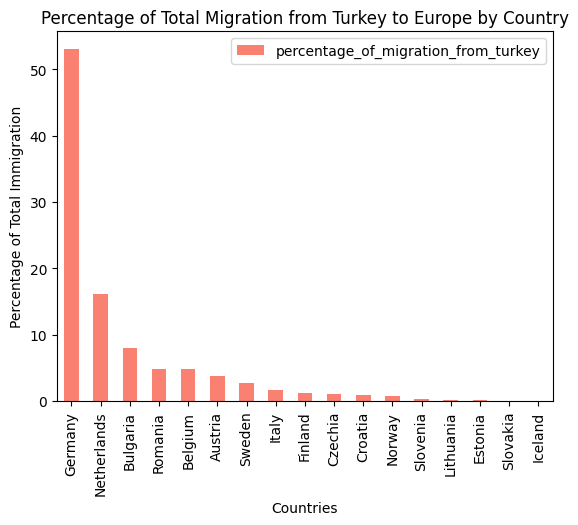

In [ ]:
migration_df_sorted.plot(x='geo', y='percentage_of_migration_from_turkey', kind='bar', color='salmon')
plt.title('Percentage of Total Migration from Turkey to Europe by Country')
plt.xlabel('Countries')
plt.ylabel('Percentage of Total Immigration')
plt.show()

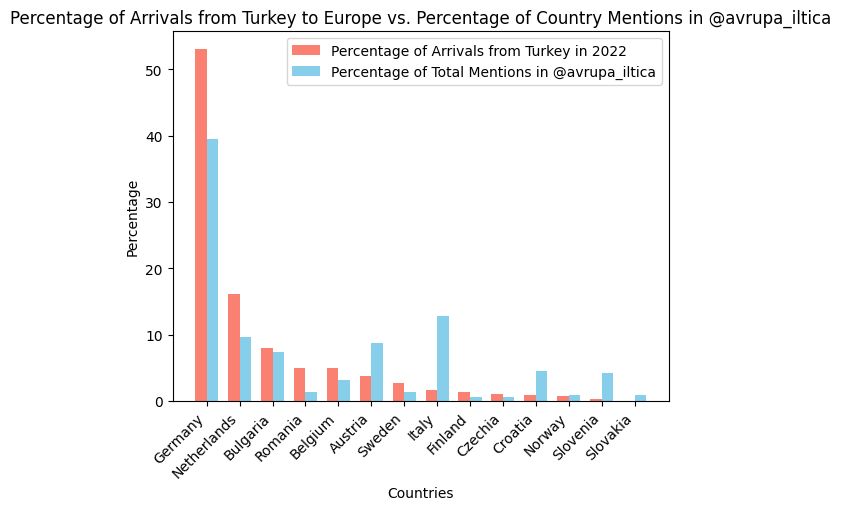

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

width = 0.35
fig, ax = plt.subplots()

ax.bar(EU_and_Telegram_df.index - width/2, EU_and_Telegram_df['percentage_of_migration_from_turkey'], width, color='salmon', label='Percentage of Arrivals from Turkey in 2022')

ax.bar(EU_and_Telegram_df.index + width/2, EU_and_Telegram_df['Percentages of Mentions'], width, color='skyblue', label='Percentage of Total Mentions in @avrupa_iltica')

ax.set_xticks(EU_and_Telegram_df.index)
ax.set_xticklabels(EU_and_Telegram_df['geo'])
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.legend()
plt.title('Percentage of Arrivals from Turkey to Europe vs. Percentage of Country Mentions in @avrupa_iltica')
plt.xlabel('Countries')
plt.ylabel('Percentage')
# Show the plot
plt.show()

The graph above shows that the number of times a country is mentioned within the Telegram channel corresponds closely to how many immigrants that country actually received from individuals whose previous residence was Turkey. I wanted to see if the data were statistically comparable, so below I used a t-test to compare the two columns of data. A t-test compares if the data are statistically *different* from one another; my t-test showed that I cannot reject the null hypothesis, i.e. *cannot say that the data are dissimilar*. This is what I hoped to show and confirms what the graph shows visibly; the Telegram data shows an approximation of migration trends with several key differences due to the Telegram data showing irregular rather than regular migration (e.g., Italy has a disproportionate representation in the Telegram data because human smuggling routes access it easily through Slovenia).

In [ ]:
from scipy.stats import ttest_rel

t_stat, p_value = ttest_rel(EU_and_Telegram_df['percentage_of_migration_from_turkey'], EU_and_Telegram_df['Percentages of Mentions'])

alpha = 0.1
t_stat, p_value
if p_value < alpha:
    result = 'Reject the Null Hypothesis'
else:
    result = 'Cannot Reject the Null Hypothesis'

result

'Cannot Reject the Null Hypothesis'

### **3.d) Comparing Data Between Telegram Channels**
Lastly, I scraped an additional Telegram channel (@avrupagocveiltica) with similar characteristics. Both channels contain over 1,000 members, were active during the period, and contain similar smuggling advertisements. I used the same scraping code as can be seen on my GitHub and saved the data as an additional csv file.

In [ ]:
data2_df= pd.read_csv(f"{path}/FINAL_Test_with_02196.csv", delimiter=',', encoding='utf-8')
pd.set_option('display.max_colwidth', None)
data2_df

Type               Group   Author ID  \
0     text  @avrupagocveiltica  6252255259   
1     text  @avrupagocveiltica  6252255259   
2     text  @avrupagocveiltica   820594448   
3     text  @avrupagocveiltica  6988310103   
4     text  @avrupagocveiltica  6988310103   
...    ...                 ...         ...   
2191  text  @avrupagocveiltica   111488712   
2192  text  @avrupagocveiltica   111488712   
2193  text  @avrupagocveiltica  6951841907   
2194  text  @avrupagocveiltica  6735464937   
2195  text  @avrupagocveiltica  6252255259   

                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                          Content  \
0     Avrupa Göç ve İltica Hizmetleri – Güvenilir ve Profesyonel Çözümler\n\n1. Avukat Tarafından Hazırlanan İltica Savunma Metni – 200 Euro\n\nİltica başvurunuzun başarı şansını artırmak için alanında uzman avukatlarımız tarafından titizlikle hazırlanmış savunma metni sunuyoruz. Savunma metni, hukuki süreçlerinizi destekleyerek başvurunuzun güçlü bir şekilde sunulmasını sağlar. Bu hizmetin ücreti 200 Euro olup, ödeme peşin olarak alınmaktadır.\n\n2. İltica Savunmasını Destekleyen Haber Çalışması – 300 Euro\n\nİltica başvurunuzu daha güçlü kılmak için sizinle ilgili geçmişe dönük, prestijli haber sitelerinde (Milliyet, Haber Türk, Haberler.com) haber yapıyoruz. Bu hizmet, başvurunuzun hukuki açıdan daha sağlam temellere oturmasına yardımcı olur. Hizmet bedeli 300 Euro olup, ödeme peşin alınır.\n\n3. Tam Kapsamlı İltica Onayı Hizmeti – 3.000 Euro\n\nEğer her detayı kapsayan, eksiksiz belgelerle doğrudan iltica onayı almak istiyorsanız, size özel hazırladığımız tam kapsam

In [ ]:
data2_df['Date'] = pd.to_datetime(data_df['Date'], format='ISO8601')

In [ ]:
combined_content2 = data2_df['Content'].to_string(index=False)
with open('combined_content2.txt', 'w') as f:
  # Write the string to the file
  f.write(combined_content2)

In [ ]:
tokens2 = nltk.word_tokenize(combined_content2)
nltk_combined2 = nltk.Text(tokens2)
tokens_lower2 = [t.lower() for t in nltk_combined2 if t.isalnum()] #
no_stops2 = [t for t in tokens_lower2 if t not in stop_words]
no_stops2

['avrupa',
 'göç',
 'i̇ltica',
 'hizmetleri',
 'güvenilir',
 'profesyonel',
 'avukat',
 'hazırlanan',
 'i̇ltica',
 'savunma',
 'metni',
 '200',
 'başvurunuzun',
 'başarı',
 'şansını',
 'artırmak',
 'alanında',
 'uzman',
 'avukatlarımız',
 'titizlikle',
 'hazırlanmış',
 'savunma',
 'metni',
 'sunuyoruz',
 'savunma',
 'metni',
 'hukuki',
 'süreçlerinizi',
 'destekleyerek',
 'başvurunuzun',
 'güçlü',
 'şekilde',
 'sunulmasını',
 'sağlar',
 'hizmetin',
 'ücreti',
 '200',
 'euro',
 'ödeme',
 'peşin',
 'i̇ltica',
 'savunmasını',
 'destekleyen',
 'haber',
 'çalışması',
 '300',
 'başvurunuzu',
 'güçlü',
 'kılmak',
 'sizinle',
 'geçmişe',
 'dönük',
 'prestijli',
 'haber',
 'sitelerinde',
 'milliyet',
 'haber',
 'türk',
 'haber',
 'yapıyoruz',
 'hizmet',
 'başvurunuzun',
 'hukuki',
 'açıdan',
 'sağlam',
 'temellere',
 'oturmasına',
 'yardımcı',
 'hizmet',
 'bedeli',
 '300',
 'euro',
 'ödeme',
 'peşin',
 'kapsamlı',
 'i̇ltica',
 'onayı',
 'hizmeti',
 'detayı',
 'kapsayan',
 'eksiksiz',
 'belgeler

In [ ]:
my_dist2 = FreqDist(no_stops2)
my_dist2


FreqDist({'iltica': 203, 'almanya': 92, 'geri': 63, 'yol': 60, 'ay': 52, 'para': 48, 'bilgisi': 47, 'parmak': 47, 'abi': 46, 'yardımcı': 45, ...})

In [ ]:
# This frequency is sorted by the most common terms in @avrupa_iltica
frequencies_df = pd.DataFrame(my_dist.items(), columns=['Term', 'Frequency in @avrupa_iltica'])
frequencies_df2 = pd.DataFrame(my_dist2.items(), columns=['Term', 'Frequency in @avrupagocveiltica'])
combined_frequencies_df = pd.merge(frequencies_df, frequencies_df2, on='Term')
combined_frequencies_sorted_df = combined_frequencies_df.sort_values(by='Frequency in @avrupa_iltica', ascending=False)
combined_frequencies_20_df = combined_frequencies_sorted_df.head(20)
combined_frequencies_20_df.index = range(1, len(combined_frequencies_20_df) + 1)
cleaned_df = combined_frequencies_20_df
print(cleaned_df)

        Term  Frequency in @avrupa_iltica  Frequency in @avrupagocveiltica
1     iltica                          169                              203
2    almanya                          123                               92
3        yol                           89                               60
4     avrupa                           87                               39
5     parmak                           84                               47
6   yardımcı                           82                               45
7        abi                           77                               46
8     gitmek                           75                               20
9       euro                           75                               32
10     bosna                           73                               42
11       izi                           68                               30
12     bilgi                           68                               38
13        ay             

In [ ]:
# This frequency is sorted by the most common terms in the second channel, @avrupagocveiltica
combined_frequencies_sorted_df2 = combined_frequencies_df.sort_values(by='Frequency in @avrupagocveiltica', ascending=False)
combined_frequencies_20_df2 = combined_frequencies_sorted_df2.head(20)
combined_frequencies_20_df2.index = range(1, len(combined_frequencies_20_df) + 1)
print(combined_frequencies_20_df2)

        Term  Frequency in @avrupa_iltica  Frequency in @avrupagocveiltica
1     iltica                          169                              203
2    almanya                          123                               92
3       geri                           53                               63
4        yol                           89                               60
5         ay                           66                               52
6       para                           49                               48
7    bilgisi                           46                               47
8     parmak                           84                               47
9        abi                           77                               46
10  yardımcı                           82                               45
11     bosna                           73                               42
12     kaçak                           61                               41
13  pasaport             

In [ ]:
sum_avrupa_iltica_20 = cleaned_df['Frequency in @avrupa_iltica'].sum()
combined_frequencies_20_df.loc[:, 'Percentage Keyword @avrupa_iltica'] = (combined_frequencies_20_df['Frequency in @avrupa_iltica'] / sum_avrupa_iltica_20) * 100


In [ ]:
sum_avrupagocveiltica_20 = cleaned_df['Frequency in @avrupagocveiltica'].sum()
combined_frequencies_20_df.loc[:, 'Percentage Keyword @avrupagocveiltica'] = (combined_frequencies_20_df['Frequency in @avrupagocveiltica'] / sum_avrupa_iltica_20) * 100

In [ ]:
combined_frequencies_20_df

,Term,Frequency in @avrupa_iltica,Frequency in @avrupagocveiltica,Percentage Keyword @avrupa_iltica,Percentage Keyword @avrupagocveiltica
1,iltica,169,203,11.024136,13.242009
2,almanya,123,92,8.023483,6.001305
3,yol,89,60,5.805610,3.913894
4,avrupa,87,39,5.675147,2.544031
5,parmak,84,47,5.479452,3.065884
6,yardımcı,82,45,5.348989,2.935421
7,abi,77,46,5.022831,3.000652
8,gitmek,75,20,4.892368,1.304631
9,euro,75,32,4.892368,2.087410
10,bosna,73,42,4.761905,2.739726


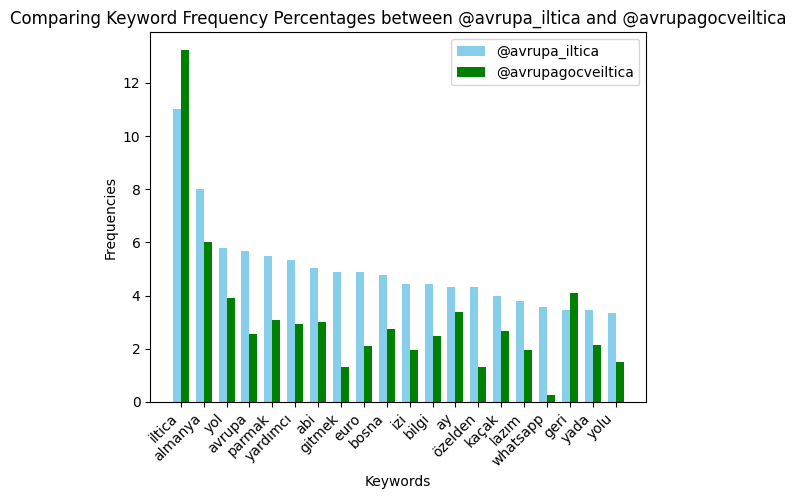

In [ ]:
width = 0.35
fig, ax = plt.subplots()

ax.bar(combined_frequencies_20_df.index - width/2, combined_frequencies_20_df['Percentage Keyword @avrupa_iltica'], width = 0.35, color='skyblue', label='@avrupa_iltica')

ax.bar(combined_frequencies_20_df.index + width/2, combined_frequencies_20_df['Percentage Keyword @avrupagocveiltica'], width = 0.35, color='green', label='@avrupagocveiltica')

ax.set_xticks(combined_frequencies_20_df.index)
ax.set_xticklabels(combined_frequencies_20_df['Term'])
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.legend()
plt.title('Comparing Keyword Frequency Percentages between @avrupa_iltica and @avrupagocveiltica')
plt.xlabel('Keywords')
plt.ylabel('Frequencies')
plt.show()

Similar to my above comparison of European Commission data with Telegram data, I created the graph and dataframes above to depict differences in frequent words across the two Telegram channels. While many common keywords exist between the channels, notably "asylum" (iltica), "Germany," (Almanya), and "road" (yol), differences between the two channels also exist. The second channel includes words like "passport" and "visa," potentially indicating that other forms of related immigration fraud are being advertised.

## **4. Conclusion and Further Research**

My research showed that discourse in online channels where human smugglers advertise their services mirrors general immigration patterns between Turkey and the European Union. Implications of this research include:


*   Telegram channels containing advertisements for human smuggling often maintain a colloquial, familiar tone; smugglers address potential clients as "friend," "brother," and "sibling," potentially to detract from the potential danger and illegality of organized immigration crime.
*   The countries most frequently mentioned within the human smuggling channel @avrupa_iltica mimic closely those with the largest immigration from Turkey during the period. Notable exceptions include spikes in the Telegram numbers for Italy and Croatia. Italy shares a porous border with Slovenia along a popular route for smugglers, and Croatia is often a starting point for smuggling routes.
*   Differences between various smuggling channels may exist, particularly based on what services an advertiser offers. Some may only offer smuggling, while others may also contain advertisements for passports, visas, and other services.

In summary, my research has shown that Turkish language Telegram channels contain useful information regarding the actions of human smugglers and the services they offer. This code could be used to analyze similar kinds of channels on Telegram in other languages.


